In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.svm import SVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, auc
)

from qiskit.circuit.library import zz_feature_map
from qiskit.primitives import StatevectorSampler
from qiskit_machine_learning.state_fidelities import ComputeUncompute
from qiskit_machine_learning.kernels import FidelityQuantumKernel

RANDOM_STATE = 42
N_QUBITS = 4
TEST_SIZE = 0.20

np.random.seed(RANDOM_STATE)


In [2]:
data = load_breast_cancer()

X = data.data
y = data.target

print("Dataset shape :", X.shape)
print("Samples       :", X.shape[0])
print("Features      :", X.shape[1])
print("Target names  :", data.target_names)
print("Class counts  :", np.bincount(y))


Dataset shape : (569, 30)
Samples       : 569
Features      : 30
Target names  : ['malignant' 'benign']
Class counts  : [212 357]


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training samples:", len(X_train))
print("Testing samples :", len(X_test))
print("Training classes:", np.bincount(y_train))
print("Testing classes :", np.bincount(y_test))


Training samples: 455
Testing samples : 114
Training classes: [170 285]
Testing classes : [42 72]


In [4]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Training shape:", X_train_scaled.shape)
print("Testing shape :", X_test_scaled.shape)


Training shape: (455, 30)
Testing shape : (114, 30)


In [5]:
pca = PCA(
    n_components=N_QUBITS,
    random_state=RANDOM_STATE
)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("PCA training shape:", X_train_pca.shape)
print("PCA testing shape :", X_test_pca.shape)

print("\nExplained variance ratio:")
for i, value in enumerate(pca.explained_variance_ratio_, 1):
    print(f"PC{i}: {value:.6f}")

print(
    "\nTotal explained variance:",
    f"{pca.explained_variance_ratio_.sum():.6f}"
)


PCA training shape: (455, 4)
PCA testing shape : (114, 4)

Explained variance ratio:
PC1: 0.444135
PC2: 0.189446
PC3: 0.095434
PC4: 0.067247

Total explained variance: 0.796262


In [6]:
angle_scaler = MinMaxScaler(
    feature_range=(0, np.pi)
)

X_train_q = angle_scaler.fit_transform(X_train_pca)
X_test_q = angle_scaler.transform(X_test_pca)

print("Quantum feature shape:", X_train_q.shape)
print("Training angle range:",
      X_train_q.min(), "to", X_train_q.max())
print("Testing angle range :",
      X_test_q.min(), "to", X_test_q.max())


Quantum feature shape: (455, 4)
Training angle range: 0.0 to 3.141592653589793
Testing angle range : -0.0450708149209198 to 3.7205100530536246


   ┌───┐┌───────────┐                                               »
0: ┤ H ├┤ P(2*x[0]) ├──■────────────────────────────────────■────■──»
   ├───┤├───────────┤┌─┴─┐┌──────────────────────────────┐┌─┴─┐  │  »
1: ┤ H ├┤ P(2*x[1]) ├┤ X ├┤ P((-π + x[0])*(-π + x[1])*2) ├┤ X ├──┼──»
   ├───┤├───────────┤└───┘└──────────────────────────────┘└───┘┌─┴─┐»
2: ┤ H ├┤ P(2*x[2]) ├──────────────────────────────────────────┤ X ├»
   ├───┤├───────────┤                                          └───┘»
3: ┤ H ├┤ P(2*x[3]) ├───────────────────────────────────────────────»
   └───┘└───────────┘                                               »
«                                                                             »
«0: ──────────────────────────────────■────■──────────────────────────────────»
«                                     │    │                                  »
«1: ──────────────────────────────────┼────┼─────────────────■────────────────»
«   ┌──────────────────────────────┐┌─┴─┐  │      

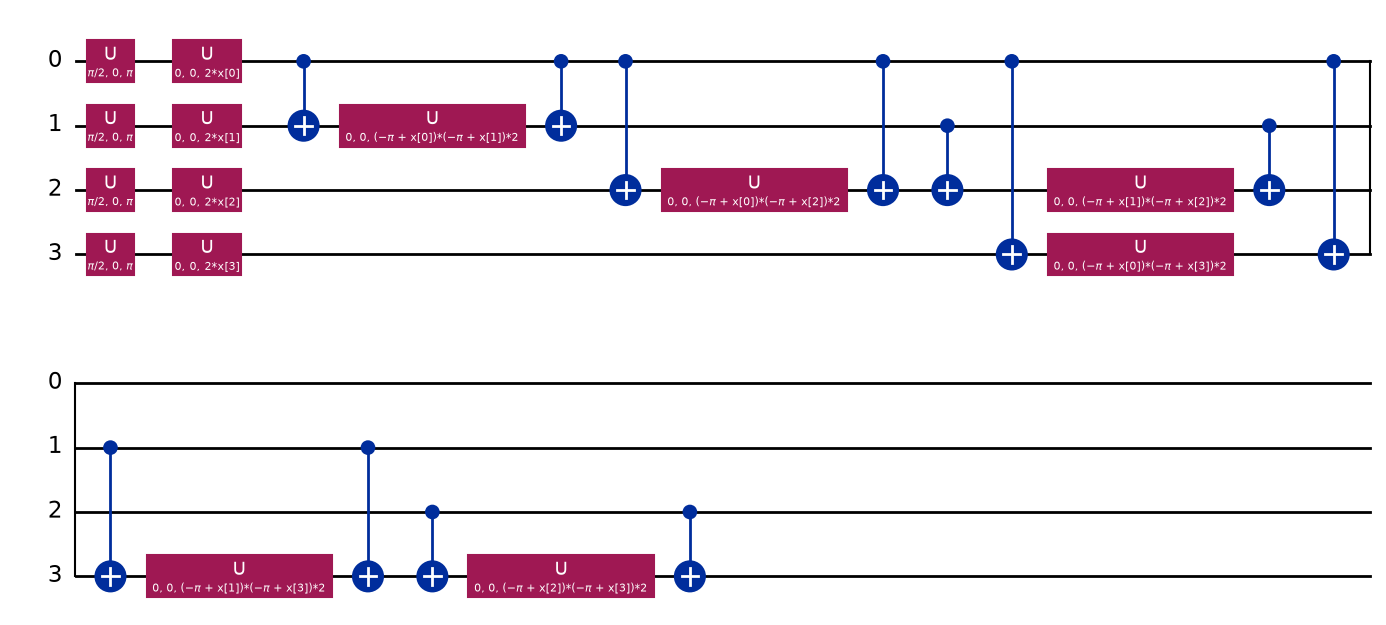

In [7]:
feature_map = zz_feature_map(
    feature_dimension=N_QUBITS,
    reps=1,
    entanglement="full"
)

print(feature_map)

display(
    feature_map.decompose().draw(
        output="mpl",
        fold=20
    )
)


In [8]:
sampler = StatevectorSampler()

fidelity = ComputeUncompute(
    sampler=sampler
)

quantum_kernel = FidelityQuantumKernel(
    feature_map=feature_map,
    fidelity=fidelity
)

print("Quantum kernel initialized.")


Quantum kernel initialized.


In [9]:
print("Computing training quantum kernel...")

K_train = quantum_kernel.evaluate(
    X_train_q
)

print("Computing test-to-training quantum kernel...")

K_test = quantum_kernel.evaluate(
    X_test_q,
    X_train_q
)

print("\nKernel shapes:")
print("K_train:", K_train.shape)
print("K_test :", K_test.shape)

assert K_train.shape == (len(X_train), len(X_train))
assert K_test.shape == (len(X_test), len(X_train))

print("\nKernel dimensions are correct.")


Computing training quantum kernel...
Computing test-to-training quantum kernel...

Kernel shapes:
K_train: (455, 455)
K_test : (114, 455)

Kernel dimensions are correct.


In [10]:
print("Quantum Kernel Diagnostics")
print("==========================")
print(f"Mean           : {np.mean(K_train):.6f}")
print(f"Std            : {np.std(K_train):.6f}")
print(f"Min            : {np.min(K_train):.6f}")
print(f"Max            : {np.max(K_train):.6f}")
print(f"Diagonal mean  : {np.mean(np.diag(K_train)):.6f}")
print(f"Diagonal std   : {np.std(np.diag(K_train)):.6f}")


Quantum Kernel Diagnostics
Mean           : 0.101307
Std            : 0.115343
Min            : -0.007523
Max            : 1.078846
Diagonal mean  : 1.040452
Diagonal std   : 0.016631


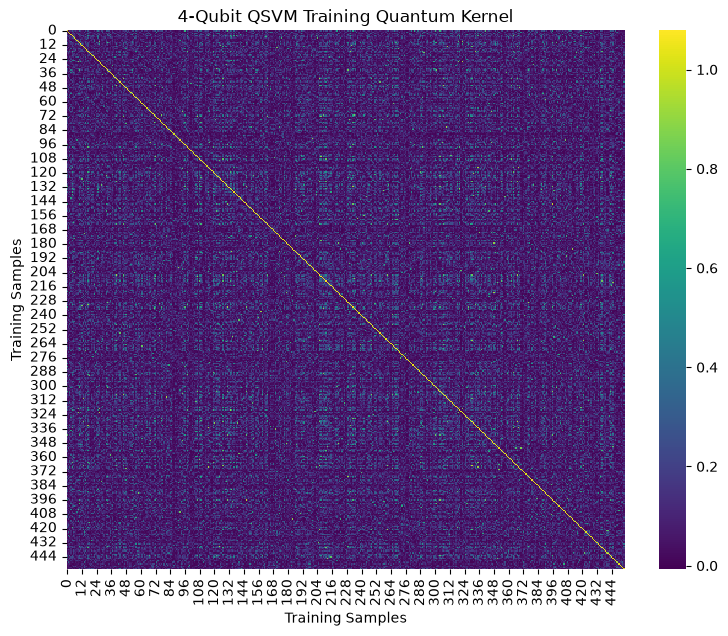

In [11]:
plt.figure(figsize=(9, 7))
sns.heatmap(K_train, cmap="viridis")
plt.title("4-Qubit QSVM Training Quantum Kernel")
plt.xlabel("Training Samples")
plt.ylabel("Training Samples")
plt.show()


In [12]:
final_qsvm = SVC(
    kernel="precomputed",
    C=0.1,
    class_weight=None
)

final_qsvm.fit(
    K_train,
    y_train
)

print("Final QSVM trained successfully.")


Final QSVM trained successfully.


In [13]:
y_pred = final_qsvm.predict(K_test)
y_score = final_qsvm.decision_function(K_test)

print("Predictions generated:", len(y_pred))


Predictions generated: 114


In [14]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
f1 = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_score)

print("FINAL 4-QUBIT QSVM RESULTS")
print("==========================")
print(f"Accuracy : {accuracy:.6f} ({accuracy*100:.2f}%)")
print(f"Precision: {precision:.6f} ({precision*100:.2f}%)")
print(f"Recall   : {recall:.6f} ({recall*100:.2f}%)")
print(f"F1-score : {f1:.6f} ({f1*100:.2f}%)")
print(f"ROC-AUC  : {roc_auc:.6f} ({roc_auc*100:.2f}%)")


FINAL 4-QUBIT QSVM RESULTS
Accuracy : 0.921053 (92.11%)
Precision: 0.909091 (90.91%)
Recall   : 0.972222 (97.22%)
F1-score : 0.939597 (93.96%)
ROC-AUC  : 0.974868 (97.49%)


In [15]:
print(
    classification_report(
        y_test,
        y_pred,
        target_names=data.target_names,
        zero_division=0
    )
)


              precision    recall  f1-score   support

   malignant       0.95      0.83      0.89        42
      benign       0.91      0.97      0.94        72

    accuracy                           0.92       114
   macro avg       0.93      0.90      0.91       114
weighted avg       0.92      0.92      0.92       114



Confusion Matrix:
[[35  7]
 [ 2 70]]


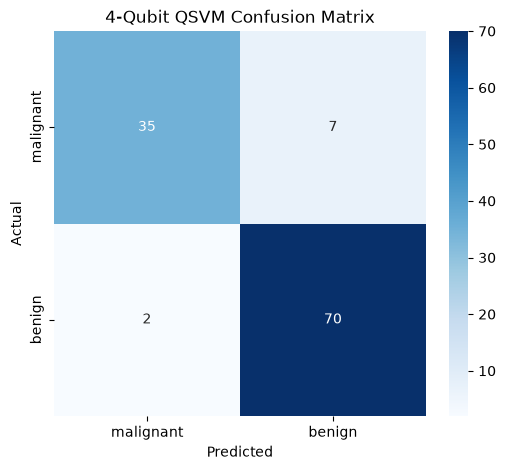

In [16]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=data.target_names,
    yticklabels=data.target_names
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("4-Qubit QSVM Confusion Matrix")
plt.show()


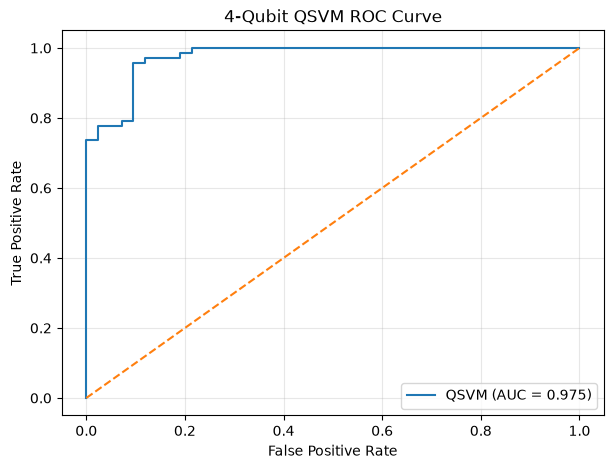

In [17]:
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc_value = auc(fpr, tpr)

plt.figure(figsize=(7, 5))
plt.plot(
    fpr, tpr,
    label=f"QSVM (AUC = {roc_auc_value:.3f})"
)
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("4-Qubit QSVM ROC Curve")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


In [18]:
final_results = pd.DataFrame([{
    "model": "QSVM",
    "dataset": "Wisconsin Breast Cancer",
    "qubits": N_QUBITS,
    "representation": "PCA_4",
    "angle_scaling": "zero_pi",
    "feature_map": "ZZ",
    "reps": 1,
    "entanglement": "full",
    "C": 0.1,
    "class_weight": "None",
    "accuracy": accuracy,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "roc_auc": roc_auc
}])

display(final_results)

final_results.to_csv(
    "final_qsvm_results.csv",
    index=False
)

print("Saved: final_qsvm_results.csv")


,model,dataset,qubits,representation,angle_scaling,feature_map,reps,entanglement,C,class_weight,accuracy,precision,recall,f1,roc_auc
0,QSVM,Wisconsin Breast Cancer,4,PCA_4,zero_pi,ZZ,1,full,0.1,None,0.921053,0.909091,0.972222,0.939597,0.974868


Saved: final_qsvm_results.csv
